# Heat Equation

The heat equation describes how temperature diffuses through a medium over time:

$$\frac{\partial T}{\partial t} = \nabla \cdot (D \nabla T)$$

where $D$ is the thermal diffusivity. We solve a 1D rod held at $T=1$ on the left and $T=0$ on the right, starting from a uniform zero temperature. The solution evolves toward the steady linear profile $T(x) = 1 - x$.

We also demonstrate a 2D example with a heated left wall.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import sys; sys.path.insert(0, '..')   # adjust path to upde.py and equations.py
# run pip install -e . to install
from upde import PDE, PDESystem, HeatEquation

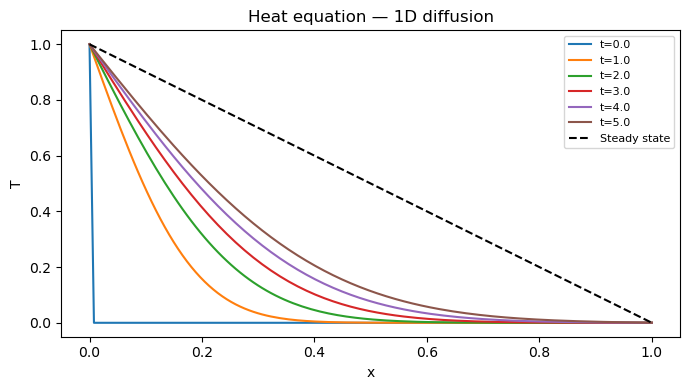

In [2]:
# ── 1D: rod with Dirichlet BCs ───────────────────────────────────────────
x  = np.linspace(0, 1, 128)
D  = 0.01

eq = HeatEquation('T', x=x, diffusivity=D)
eq.set_bc(side='left',  kind='dirichlet', value=1.0)
eq.set_bc(side='right', kind='dirichlet', value=0.0)
eq.set_ic(0.0)

sol = eq.solve(t_span=(0, 5), method='BDF',
                            t_eval=np.linspace(0, 5, 6),
                            rtol=1e-4, atol=1e-6)

# Plot profiles at several times
fig, ax = plt.subplots(figsize=(7, 4))
for k, t in enumerate(sol.t):
    ax.plot(x, sol.T[:, k], label=f't={t:.1f}')
x_ss = np.linspace(0, 1, 100)
ax.plot(x_ss, 1 - x_ss, 'k--', lw=1.5, label='Steady state')
ax.set_xlabel('x'); ax.set_ylabel('T')
ax.set_title('Heat equation — 1D diffusion')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


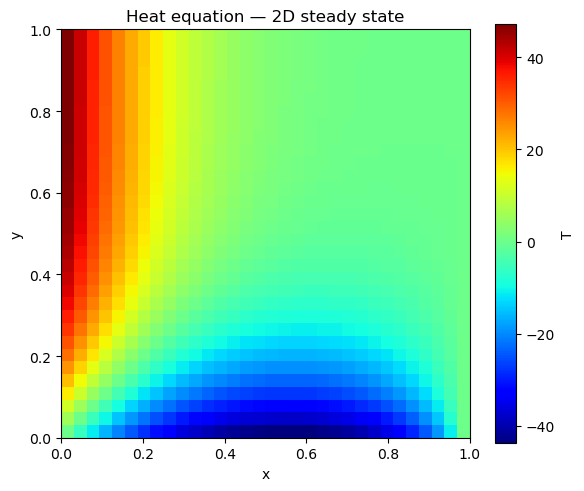

In [3]:
# ── 2D: heated left wall ─────────────────────────────────────────────────
x2 = np.linspace(0, 1, 32)
y2 = np.linspace(0, 1, 32)

eq2 = HeatEquation('T', x=x2, y=y2, diffusivity=0.01)
eq2.set_bc(side='left',   kind='neumann', value=1.0)
eq2.set_bc(side='right',  kind='dirichlet', value=0.0)
eq2.set_bc(side='bottom', kind='neumann',   value=-1.0)
eq2.set_bc(side='top',    kind='neumann',   value=0.0)
eq2.set_ic(0.0)

sol2 = eq2.solve(t_span=(0, 5), method='BDF',
                              rtol=1e-4, atol=1e-6)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sol2.T[:, :, -1].T, origin='lower', aspect='equal',
               extent=[0,1,0,1], cmap='jet')
plt.colorbar(im, ax=ax, label='T')
ax.set_title('Heat equation — 2D steady state')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()
